# Notebook 07 – Prototype Battle Engine

## Objective

The Card Knowledge Base and Deck Builder produced structured card objects and two saved 60-card decks.

In this notebook, we begin constructing a prototype Pokémon TCG Battle Engine.

The engine will eventually manage:

- Deck shuffling
- Opening hands
- Active and Benched Pokémon
- Energy attachment
- Attack selection
- Damage calculation
- Weakness and Resistance
- Knock Outs and Prize cards
- Turn progression
- Battle outcomes

This first version will focus on building a reliable battle state and validating the flow of a simulated match.

The implementation is a simplified competition prototype and will be expanded as additional simulator rules and mechanics are integrated.

## Step 1 – Import Libraries and Locate Saved Artifacts

The Battle Engine loads the Card Knowledge Base and the decks created in previous notebooks.

Using saved artifacts prevents the engine from rebuilding the entire data pipeline each time it runs.

In [1]:
from pathlib import Path
from copy import deepcopy
import pickle
import random
import math

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

KNOWLEDGE_BASE_FILE = PROCESSED_DIR / "card_knowledge_base.pkl"
STARTER_DECK_FILE = PROCESSED_DIR / "starter_deck.pkl"
LIGHTNING_DECK_FILE = PROCESSED_DIR / "lightning_deck.pkl"

print("Project Root:", PROJECT_ROOT)
print("Processed Data:", PROCESSED_DIR)

print("\nArtifact availability:")
print("Knowledge Base:", KNOWLEDGE_BASE_FILE.exists())
print("Starter Deck:", STARTER_DECK_FILE.exists())
print("Lightning Deck:", LIGHTNING_DECK_FILE.exists())

Project Root: D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\notebooks
Processed Data: D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\notebooks\data\processed

Artifact availability:
Knowledge Base: True
Starter Deck: True
Lightning Deck: True


## Step 2 – Load the Card Knowledge Base and Decks

We load the serialized card objects and both generated decks.

Deep copies will later be used during matches so that battle actions do not permanently modify the original saved deck objects.

In [2]:
def load_pickle(file_path):
    """Load and return a serialized Python object."""
    if not file_path.exists():
        raise FileNotFoundError(f"Required file was not found: {file_path}")

    with open(file_path, "rb") as file:
        return pickle.load(file)


card_knowledge_base = load_pickle(KNOWLEDGE_BASE_FILE)
starter_deck = load_pickle(STARTER_DECK_FILE)
lightning_deck = load_pickle(LIGHTNING_DECK_FILE)

print("Knowledge Base Cards:", len(card_knowledge_base))
print("Starter Deck Cards:", len(starter_deck))
print("Lightning Deck Cards:", len(lightning_deck))

Knowledge Base Cards: 1267
Starter Deck Cards: 60
Lightning Deck Cards: 60


## Observation 1

The Card Knowledge Base and both 60-card decks loaded successfully.

These artifacts provide the card definitions and player decks required to initialize a simulated battle.

## Step 3 – Inspect the Deck Object Structure

Before building the battle state, we inspect one card from each deck.

This confirms that the objects contain the fields required by the engine, including category, stage, HP, type, attacks, and retreat cost.

In [3]:
print("Starter Deck Sample:")
print(starter_deck[0])

print("\nLightning Deck Sample:")
print(lightning_deck[0])

Starter Deck Sample:
{'card_id': 249, 'name': 'Eevee ex', 'category': 'Pokémon', 'stage': 'Basic Pokémon', 'hp': 200.0, 'type': 'Colorless', 'weakness': 'Fighting', 'resistance': nan, 'retreat': 1.0, 'overall_score': 101.5, 'attacks': [{'Move Name': '[Tera]', 'Cost': nan, 'Damage': nan, 'Effect Explanation': 'As long as this Pokémon is on your Bench, prevent all damage done to this Pokémon by attacks (both yours and your opponent’s).', 'energy_cost': 0, 'damage_numeric': 0.0}, {'Move Name': '[Ability] Rainbow DNA', 'Cost': nan, 'Damage': nan, 'Effect Explanation': 'This Pokémon can evolve into any Pokémon {ex} that evolves from Eevee if you play it from your hand\xa0onto this Pokémon.\xa0(This Pokémon can’t evolve during your first turn or the turn you play it.)', 'energy_cost': 0, 'damage_numeric': 0.0}, {'Move Name': 'Coruscating Quartz', 'Cost': '{R}{W}{L}', 'Damage': '200', 'Effect Explanation': nan, 'energy_cost': 3, 'damage_numeric': 200.0}], 'rule': 'Pokémon ex', 'effect': 'As l

In [4]:
def first_card_by_category(deck, category):
    """Return the first card matching the requested category."""
    return next(
        (card for card in deck if card.get("category") == category),
        None
    )


starter_pokemon = first_card_by_category(starter_deck, "Pokémon")
lightning_pokemon = first_card_by_category(lightning_deck, "Pokémon")

print("Starter Deck Pokémon:")
print(starter_pokemon)

print("\nLightning Deck Pokémon:")
print(lightning_pokemon)

Starter Deck Pokémon:
{'card_id': 249, 'name': 'Eevee ex', 'category': 'Pokémon', 'stage': 'Basic Pokémon', 'hp': 200.0, 'type': 'Colorless', 'weakness': 'Fighting', 'resistance': nan, 'retreat': 1.0, 'overall_score': 101.5, 'attacks': [{'Move Name': '[Tera]', 'Cost': nan, 'Damage': nan, 'Effect Explanation': 'As long as this Pokémon is on your Bench, prevent all damage done to this Pokémon by attacks (both yours and your opponent’s).', 'energy_cost': 0, 'damage_numeric': 0.0}, {'Move Name': '[Ability] Rainbow DNA', 'Cost': nan, 'Damage': nan, 'Effect Explanation': 'This Pokémon can evolve into any Pokémon {ex} that evolves from Eevee if you play it from your hand\xa0onto this Pokémon.\xa0(This Pokémon can’t evolve during your first turn or the turn you play it.)', 'energy_cost': 0, 'damage_numeric': 0.0}, {'Move Name': 'Coruscating Quartz', 'Cost': '{R}{W}{L}', 'Damage': '200', 'Effect Explanation': nan, 'energy_cost': 3, 'damage_numeric': 200.0}], 'rule': 'Pokémon ex', 'effect': 'As 

## Step 4 – Create Safe Value Helpers

Some card fields contain missing values because Trainer and Energy cards do not use Pokémon battle statistics.

The engine uses helper functions to convert missing numeric values into safe defaults.

In [5]:
def safe_number(value, default=0):
    """Convert a value to a usable number while safely handling NaN."""
    if value is None:
        return default

    try:
        if math.isnan(value):
            return default
    except TypeError:
        pass

    return value


print(safe_number(float("nan")))
print(safe_number(120))
print(safe_number(None))

0
120
0


## Step 5 – Prepare a Deck for Battle

Each battle uses a shuffled copy of the saved deck.

Creating a deep copy ensures that drawing cards, attaching Energy, and applying damage do not modify the original deck artifact.

In [6]:
def prepare_deck(deck, seed=None):
    """Return a shuffled deep copy of a deck."""
    prepared_deck = deepcopy(deck)

    rng = random.Random(seed)
    rng.shuffle(prepared_deck)

    return prepared_deck


player_one_deck = prepare_deck(starter_deck, seed=42)
player_two_deck = prepare_deck(lightning_deck, seed=99)

print("Player 1 deck size:", len(player_one_deck))
print("Player 2 deck size:", len(player_two_deck))
print("Original starter deck remains:", len(starter_deck))

Player 1 deck size: 60
Player 2 deck size: 60
Original starter deck remains: 60


## Step 6 – Draw an Opening Hand

Each player begins by drawing an opening hand from the top of the shuffled deck.

For the first prototype, the opening hand contains seven cards.

In [7]:
OPENING_HAND_SIZE = 7


def draw_cards(deck, hand, number_of_cards=1):
    """Move cards from the top of the deck into the player's hand."""
    drawn_cards = []

    for _ in range(number_of_cards):
        if not deck:
            break

        card = deck.pop(0)
        hand.append(card)
        drawn_cards.append(card)

    return drawn_cards


player_one_hand = []
player_two_hand = []

draw_cards(player_one_deck, player_one_hand, OPENING_HAND_SIZE)
draw_cards(player_two_deck, player_two_hand, OPENING_HAND_SIZE)

print("Player 1 hand:", len(player_one_hand))
print("Player 1 remaining deck:", len(player_one_deck))

print("Player 2 hand:", len(player_two_hand))
print("Player 2 remaining deck:", len(player_two_deck))

Player 1 hand: 7
Player 1 remaining deck: 53
Player 2 hand: 7
Player 2 remaining deck: 53


In [8]:
def summarize_cards(cards):
    """Return a compact summary of a collection of cards."""
    return [
        {
            "name": card.get("name"),
            "category": card.get("category"),
            "stage": card.get("stage")
        }
        for card in cards
    ]


summarize_cards(player_one_hand)

[{'name': 'Strange Timepiece', 'category': 'Trainer', 'stage': 'Item'},
 {'name': 'Potion', 'category': 'Trainer', 'stage': 'Item'},
 {'name': 'Basic {M} Energy', 'category': 'Energy', 'stage': 'Basic Energy'},
 {'name': 'Rotom', 'category': 'Pokémon', 'stage': 'Basic Pokémon'},
 {'name': "Team Rocket's Ampharos",
  'category': 'Pokémon',
  'stage': 'Stage 2 Pokémon'},
 {'name': "Lillie's Determination",
  'category': 'Trainer',
  'stage': 'Supporter'},
 {'name': 'Enriching Energy', 'category': 'Energy', 'stage': 'Special Energy'}]

## Observation 2

Both decks were copied, shuffled, and reduced from 60 to 53 cards after drawing seven-card opening hands.

The next phase will verify that each player has a Basic Pokémon available and implement a simplified mulligan procedure when an opening hand contains none.

## Step 7 – Check for Basic Pokémon and Handle Mulligans

A valid opening hand must contain at least one Basic Pokémon that can be placed in the Active Spot.

If a player's opening hand does not contain a Basic Pokémon, the player performs a mulligan:

- The hand is returned to the deck.
- The deck is reshuffled.
- A new seven-card hand is drawn.
- The process repeats until a Basic Pokémon is found.

This prototype records the number of mulligans but does not yet award extra cards to the opponent.

In [9]:
def get_basic_pokemon(hand):
    """Return all Basic Pokémon cards in a hand."""
    return [
        card for card in hand
        if card.get("category") == "Pokémon"
        and card.get("stage") == "Basic Pokémon"
    ]


def has_basic_pokemon(hand):
    """Return True when the hand contains at least one Basic Pokémon."""
    return len(get_basic_pokemon(hand)) > 0

In [10]:
print("Player 1 has Basic Pokémon:", has_basic_pokemon(player_one_hand))
print("Player 2 has Basic Pokémon:", has_basic_pokemon(player_two_hand))

print("Player 1 Basic Pokémon:", [
    card["name"] for card in get_basic_pokemon(player_one_hand)
])

print("Player 2 Basic Pokémon:", [
    card["name"] for card in get_basic_pokemon(player_two_hand)
])

Player 1 has Basic Pokémon: True
Player 2 has Basic Pokémon: True
Player 1 Basic Pokémon: ['Rotom']
Player 2 Basic Pokémon: ['Zapdos', 'Zeraora']


## Step 8 – Implement the Mulligan Procedure

The mulligan function repeatedly returns an invalid opening hand to the deck, reshuffles, and draws seven new cards until a Basic Pokémon is available.

A maximum mulligan limit prevents an infinite loop if a deck contains no Basic Pokémon.

In [11]:
def draw_valid_opening_hand(
    deck,
    hand_size=OPENING_HAND_SIZE,
    seed=None,
    max_mulligans=100
):
    """
    Draw an opening hand containing at least one Basic Pokémon.

    Returns:
        remaining_deck
        opening_hand
        mulligan_count
    """
    working_deck = deepcopy(deck)
    rng = random.Random(seed)
    rng.shuffle(working_deck)

    mulligan_count = 0

    while mulligan_count <= max_mulligans:
        hand = working_deck[:hand_size]
        remaining_deck = working_deck[hand_size:]

        if has_basic_pokemon(hand):
            return remaining_deck, hand, mulligan_count

        working_deck = hand + remaining_deck
        rng.shuffle(working_deck)
        mulligan_count += 1

    raise ValueError(
        "Unable to draw a valid opening hand. "
        "The deck may not contain a Basic Pokémon."
    )

In [12]:
player_one_deck, player_one_hand, player_one_mulligans = (
    draw_valid_opening_hand(
        starter_deck,
        seed=42
    )
)

player_two_deck, player_two_hand, player_two_mulligans = (
    draw_valid_opening_hand(
        lightning_deck,
        seed=99
    )
)

print("Player 1 mulligans:", player_one_mulligans)
print("Player 1 hand size:", len(player_one_hand))
print("Player 1 Basic Pokémon:", [
    card["name"] for card in get_basic_pokemon(player_one_hand)
])

print()

print("Player 2 mulligans:", player_two_mulligans)
print("Player 2 hand size:", len(player_two_hand))
print("Player 2 Basic Pokémon:", [
    card["name"] for card in get_basic_pokemon(player_two_hand)
])

Player 1 mulligans: 0
Player 1 hand size: 7
Player 1 Basic Pokémon: ['Rotom']

Player 2 mulligans: 0
Player 2 hand size: 7
Player 2 Basic Pokémon: ['Zapdos', 'Zeraora']


## Observation 3

Both players now begin with valid seven-card hands containing at least one Basic Pokémon.

The mulligan counter records how many redraws were required before each player obtained a legal opening hand.

## Step 9 – Select the Active Pokémon and Build the Bench

Each player must place one Basic Pokémon in the Active Spot.

Additional Basic Pokémon from the opening hand may be placed on the Bench.

For this prototype:

- The first available Basic Pokémon becomes the Active Pokémon.
- Up to five additional Basic Pokémon are placed on the Bench.
- All remaining cards stay in the player's hand.

In [13]:
MAX_BENCH_SIZE = 5


def setup_starting_field(hand):
    """
    Select one Basic Pokémon as Active and place up to five
    additional Basic Pokémon on the Bench.

    Returns:
        active_pokemon
        bench
        remaining_hand
    """
    basic_pokemon = get_basic_pokemon(hand)

    if not basic_pokemon:
        raise ValueError("Opening hand does not contain a Basic Pokémon.")

    active_pokemon = deepcopy(basic_pokemon[0])

    bench_candidates = basic_pokemon[1:MAX_BENCH_SIZE + 1]
    bench = [deepcopy(card) for card in bench_candidates]

    used_card_ids = {
        id(basic_pokemon[0]),
        *[id(card) for card in bench_candidates]
    }

    remaining_hand = [
        card for card in hand
        if id(card) not in used_card_ids
    ]

    return active_pokemon, bench, remaining_hand

In [14]:
player_one_active, player_one_bench, player_one_hand = (
    setup_starting_field(player_one_hand)
)

player_two_active, player_two_bench, player_two_hand = (
    setup_starting_field(player_two_hand)
)

In [15]:
print("Player 1 Active:", player_one_active["name"])
print("Player 1 Bench:", [card["name"] for card in player_one_bench])
print("Player 1 Remaining Hand:", len(player_one_hand))

print()

print("Player 2 Active:", player_two_active["name"])
print("Player 2 Bench:", [card["name"] for card in player_two_bench])
print("Player 2 Remaining Hand:", len(player_two_hand))

Player 1 Active: Rotom
Player 1 Bench: []
Player 1 Remaining Hand: 6

Player 2 Active: Zapdos
Player 2 Bench: ['Zeraora']
Player 2 Remaining Hand: 5


## Step 10 – Initialize Runtime Pokémon State

During battle, each Pokémon needs temporary runtime values that are not part of the printed card data.

These include:

- Current damage
- Attached Energy
- Knock Out status
- Active or Bench position

The engine adds these fields to copies of the original card objects.

In [16]:
def initialize_pokemon_state(card, position):
    """Create a runtime battle-state copy of a Pokémon card."""
    pokemon = deepcopy(card)

    pokemon["damage_received"] = 0
    pokemon["attached_energy"] = []
    pokemon["is_knocked_out"] = False
    pokemon["position"] = position

    pokemon["max_hp"] = safe_number(
        pokemon.get("hp"),
        default=0
    )

    pokemon["current_hp"] = pokemon["max_hp"]

    return pokemon

In [17]:
player_one_active = initialize_pokemon_state(
    player_one_active,
    position="Active"
)

player_one_bench = [
    initialize_pokemon_state(card, position="Bench")
    for card in player_one_bench
]

player_two_active = initialize_pokemon_state(
    player_two_active,
    position="Active"
)

player_two_bench = [
    initialize_pokemon_state(card, position="Bench")
    for card in player_two_bench
]

In [18]:
player_one_active

{'card_id': 212,
 'name': 'Rotom',
 'category': 'Pokémon',
 'stage': 'Basic Pokémon',
 'hp': 80.0,
 'type': 'Lightning',
 'weakness': 'Fighting',
 'resistance': nan,
 'retreat': 1.0,
 'overall_score': 40.5,
 'attacks': [{'Move Name': 'Crushing Pulse',
   'Cost': '{L}',
   'Damage': nan,
   'Effect Explanation': 'Your opponent reveals their hand. Discard all Item cards and Pokémon Tool cards you find there.',
   'energy_cost': 1,
   'damage_numeric': 0.0},
  {'Move Name': 'Energy Short',
   'Cost': '{L}',
   'Damage': '20×',
   'Effect Explanation': 'This attack does 20 damage for each Energy attached to your opponent’s Active Pokémon.',
   'energy_cost': 1,
   'damage_numeric': 0.0}],
 'rule': nan,
 'effect': 'Your opponent reveals their hand. Discard all Item cards and Pokémon Tool cards you find there.',
 'damage_received': 0,
 'attached_energy': [],
 'is_knocked_out': False,
 'position': 'Active',
 'max_hp': 80.0,
 'current_hp': 80.0}

## Observation 4

Both players now have an Active Pokémon and an initialized Bench.

Each Pokémon also contains runtime battle fields for HP, damage, attached Energy, position, and Knock Out status.

The next step is to create a complete Player State object that stores the deck, hand, Active Pokémon, Bench, discard pile, Prize cards, and turn information.

## Step 11 – Create Complete Player State

The Battle Engine needs one structured object for each player.

The Player State stores:

- Player name
- Remaining deck
- Current hand
- Active Pokémon
- Benched Pokémon
- Discard pile
- Prize cards
- Mulligan count
- Turn number
- Whether Energy has been attached this turn

This structure will make future battle actions easier to manage and validate.

In [20]:
PRIZE_CARD_COUNT = 6


def create_player_state(
    player_name,
    deck,
    hand,
    active_pokemon,
    bench,
    mulligan_count=0
):
    """
    Create a complete player battle-state dictionary.
    """
    working_deck = deepcopy(deck)

    prize_cards = working_deck[:PRIZE_CARD_COUNT]
    remaining_deck = working_deck[PRIZE_CARD_COUNT:]

    return {
        "name": player_name,
        "deck": remaining_deck,
        "hand": deepcopy(hand),
        "active": deepcopy(active_pokemon),
        "bench": deepcopy(bench),
        "discard_pile": [],
        "prize_cards": prize_cards,
        "mulligans": mulligan_count,
        "turn_number": 0,
        "energy_attached_this_turn": False,
        "has_drawn_this_turn": False
    }

In [21]:
player_one = create_player_state(
    player_name="Player 1",
    deck=player_one_deck,
    hand=player_one_hand,
    active_pokemon=player_one_active,
    bench=player_one_bench,
    mulligan_count=player_one_mulligans
)

player_two = create_player_state(
    player_name="Player 2",
    deck=player_two_deck,
    hand=player_two_hand,
    active_pokemon=player_two_active,
    bench=player_two_bench,
    mulligan_count=player_two_mulligans
)

## Step 12 – Summarize the Starting Battle State

A compact summary function makes it easier to inspect the current match without printing every card object in full.

In [22]:
def summarize_player_state(player):
    """Return a compact summary of a player's current battle state."""
    return {
        "player": player["name"],
        "deck_size": len(player["deck"]),
        "hand_size": len(player["hand"]),
        "active_pokemon": player["active"]["name"],
        "active_hp": player["active"]["current_hp"],
        "bench": [card["name"] for card in player["bench"]],
        "bench_size": len(player["bench"]),
        "discard_size": len(player["discard_pile"]),
        "prize_cards": len(player["prize_cards"]),
        "mulligans": player["mulligans"],
        "turn_number": player["turn_number"]
    }

In [23]:
summarize_player_state(player_one)

{'player': 'Player 1',
 'deck_size': 47,
 'hand_size': 6,
 'active_pokemon': 'Rotom',
 'active_hp': 80.0,
 'bench': [],
 'bench_size': 0,
 'discard_size': 0,
 'prize_cards': 6,
 'mulligans': 0,
 'turn_number': 0}

## Observation 5

Both players now have complete battle-state objects.

Each Player State contains a deck, hand, Active Pokémon, Bench, discard pile, Prize cards, and turn-tracking fields.

This provides the central data structure needed for drawing cards, attaching Energy, attacking, retreating, taking Prize cards, and determining the winner.

# Step 13 – Start a Player Turn

Every turn begins with several actions.

For this prototype we implement:

1. Increase the turn number.
2. Reset once-per-turn actions.
3. Draw one card.
4. Report the current game state.

Future versions will include:

- Energy attachment
- Trainer cards
- Retreating
- Attacking
- End-of-turn effects

In [24]:
def start_turn(player):
    """
    Start a player's turn.
    """

    player["turn_number"] += 1

    player["energy_attached_this_turn"] = False
    player["has_drawn_this_turn"] = False

    if len(player["deck"]) > 0:

        drawn_card = player["deck"].pop(0)

        player["hand"].append(drawn_card)

        player["has_drawn_this_turn"] = True

        print(f'{player["name"]} drew:')

        print(drawn_card["name"])

    else:

        print(f'{player["name"]} cannot draw a card.')
        print("Deck is empty!")

    return player

In [25]:
player_one = start_turn(player_one)

Player 1 drew:
Team Rocket's Giovanni


In [26]:
summarize_player_state(player_one)

{'player': 'Player 1',
 'deck_size': 46,
 'hand_size': 7,
 'active_pokemon': 'Rotom',
 'active_hp': 80.0,
 'bench': [],
 'bench_size': 0,
 'discard_size': 0,
 'prize_cards': 6,
 'mulligans': 0,
 'turn_number': 1}

## Step 14 – Display the Active Pokémon

A helper function summarizes the Active Pokémon during battle.

Future turns will repeatedly display this information after attacks and damage calculations.

In [27]:
def display_active_pokemon(player):

    pokemon = player["active"]

    print("=" * 40)

    print(player["name"])

    print("=" * 40)

    print("Active Pokémon :", pokemon["name"])

    print("HP :", pokemon["current_hp"], "/", pokemon["max_hp"])

    print("Type :", pokemon["type"])

    print("Damage Received :", pokemon["damage_received"])

    print("Attached Energy :", len(pokemon["attached_energy"]))

    print("=" * 40)

In [28]:
display_active_pokemon(player_one)

Player 1
Active Pokémon : Rotom
HP : 80.0 / 80.0
Type : Lightning
Damage Received : 0
Attached Energy : 0


## Step 15 – Show Both Players

In [29]:
display_active_pokemon(player_one)

display_active_pokemon(player_two)

Player 1
Active Pokémon : Rotom
HP : 80.0 / 80.0
Type : Lightning
Damage Received : 0
Attached Energy : 0
Player 2
Active Pokémon : Zapdos
HP : 110.0 / 110.0
Type : Lightning
Damage Received : 0
Attached Energy : 0


## Observation 6

The Battle Engine has now completed its first complete turn initialization.

Each player has:

- a validated deck
- an opening hand
- Prize cards
- an Active Pokémon
- a Bench
- a battle state
- turn tracking
- card draw
- battle display

The engine is now ready to begin implementing gameplay mechanics such as Energy attachment, attack selection, damage calculation, Knock Outs, and Prize card collection.

# Step 16 – Attach Energy to the Active Pokémon

A player may normally attach one Energy card from their hand during each turn.

For this prototype:

- Only cards in the Energy category may be attached.
- Energy is attached to the Active Pokémon.
- A player may attach only one Energy per turn.
- The attached Energy card is removed from the hand.

In [30]:
def get_energy_cards_from_hand(player):
    """Return all Energy cards currently in the player's hand."""
    return [
        card for card in player["hand"]
        if card.get("category") == "Energy"
    ]


def attach_energy_to_active(player, energy_card=None):
    """
    Attach one Energy card from the player's hand
    to the Active Pokémon.
    """
    if player["energy_attached_this_turn"]:
        return {
            "success": False,
            "message": "Energy has already been attached this turn."
        }

    available_energy = get_energy_cards_from_hand(player)

    if not available_energy:
        return {
            "success": False,
            "message": "No Energy card is available in the hand."
        }

    if energy_card is None:
        energy_card = available_energy[0]

    if energy_card not in available_energy:
        return {
            "success": False,
            "message": "The selected card is not an available Energy card."
        }

    player["hand"].remove(energy_card)
    player["active"]["attached_energy"].append(deepcopy(energy_card))
    player["energy_attached_this_turn"] = True

    return {
        "success": True,
        "message": (
            f'{player["name"]} attached {energy_card["name"]} '
            f'to {player["active"]["name"]}.'
        ),
        "energy_card": energy_card["name"],
        "attached_energy_count": len(
            player["active"]["attached_energy"]
        )
    }

In [31]:
print("Energy in Player 1 hand:")

for card in get_energy_cards_from_hand(player_one):
    print("-", card["name"])

Energy in Player 1 hand:
- Basic {M} Energy
- Enriching Energy


In [32]:
attachment_result = attach_energy_to_active(player_one)

attachment_result

{'success': True,
 'message': 'Player 1 attached Basic {M} Energy to Rotom.',
 'energy_card': 'Basic {M} Energy',
 'attached_energy_count': 1}

In [33]:
display_active_pokemon(player_one)

Player 1
Active Pokémon : Rotom
HP : 80.0 / 80.0
Type : Lightning
Damage Received : 0
Attached Energy : 1


## Step 17 – Test the Once-Per-Turn Rule

In [34]:
second_attachment = attach_energy_to_active(player_one)

second_attachment

{'success': False, 'message': 'Energy has already been attached this turn.'}

## Observation 7

The Battle Engine can now identify Energy cards in a player's hand and attach one Energy to the Active Pokémon.

The attached card is removed from the hand and stored in the Active Pokémon's runtime state.

The once-per-turn Energy attachment rule is also enforced.

# Step 18 – Inspect Attacks and Check Energy Requirements

Before a Pokémon can attack, the Battle Engine must confirm that enough Energy is attached.

Each attack contains:

- Attack name
- Printed Energy cost
- Numeric Energy cost
- Damage
- Effect text

For this first prototype, we compare the total number of attached Energy cards with the engineered numeric Energy cost.

In [35]:
def get_valid_attacks(pokemon):
    """Return attacks that contain a usable move name."""
    return [
        attack for attack in pokemon.get("attacks", [])
        if attack.get("Move Name") is not None
        and not (
            isinstance(attack.get("Move Name"), float)
            and math.isnan(attack.get("Move Name"))
        )
    ]


def count_attached_energy(pokemon):
    """Return the total number of Energy cards attached."""
    return len(pokemon.get("attached_energy", []))


def can_use_attack(pokemon, attack):
    """
    Check whether a Pokémon has enough attached Energy
    to use a selected attack.
    """
    required_energy = int(
        safe_number(
            attack.get("energy_cost"),
            default=0
        )
    )

    attached_energy = count_attached_energy(pokemon)

    return attached_energy >= required_energy

In [36]:
player_one_attacks = get_valid_attacks(player_one["active"])

print("Active Pokémon:", player_one["active"]["name"])
print("Attached Energy:", count_attached_energy(player_one["active"]))
print()

for index, attack in enumerate(player_one_attacks, start=1):
    print(f"Attack {index}")
    print("Name:", attack.get("Move Name"))
    print("Printed Cost:", attack.get("Cost"))
    print("Numeric Cost:", attack.get("energy_cost"))
    print("Damage:", attack.get("Damage"))
    print("Can Use:", can_use_attack(player_one["active"], attack))
    print("-" * 40)

Active Pokémon: Rotom
Attached Energy: 1

Attack 1
Name: Crushing Pulse
Printed Cost: {L}
Numeric Cost: 1
Damage: nan
Can Use: True
----------------------------------------
Attack 2
Name: Energy Short
Printed Cost: {L}
Numeric Cost: 1
Damage: 20×
Can Use: True
----------------------------------------


## Step 19 – Identify Usable Attacks

The engine filters the Active Pokémon's attack list and returns only attacks whose Energy requirements are currently satisfied.

In [37]:
def get_usable_attacks(pokemon):
    """Return all attacks the Pokémon can currently use."""
    return [
        attack for attack in get_valid_attacks(pokemon)
        if can_use_attack(pokemon, attack)
    ]

In [38]:
usable_attacks = get_usable_attacks(player_one["active"])

print("Usable attacks for", player_one["active"]["name"])

if usable_attacks:
    for attack in usable_attacks:
        print(
            "-",
            attack.get("Move Name"),
            "| Damage:",
            attack.get("damage_numeric"),
            "| Energy Cost:",
            attack.get("energy_cost")
        )
else:
    print("No attacks are currently usable.")

Usable attacks for Rotom
- Crushing Pulse | Damage: 0.0 | Energy Cost: 1
- Energy Short | Damage: 0.0 | Energy Cost: 1


## Step 20 – Create an Attack Summary Helper

In [39]:
def summarize_attack_options(player):
    """Return a compact summary of the Active Pokémon's attacks."""
    pokemon = player["active"]

    return [
        {
            "move_name": attack.get("Move Name"),
            "printed_cost": attack.get("Cost"),
            "energy_cost": int(
                safe_number(
                    attack.get("energy_cost"),
                    default=0
                )
            ),
            "damage": safe_number(
                attack.get("damage_numeric"),
                default=0
            ),
            "attached_energy": count_attached_energy(pokemon),
            "can_use": can_use_attack(pokemon, attack)
        }
        for attack in get_valid_attacks(pokemon)
    ]

In [40]:
summarize_attack_options(player_one)


[{'move_name': 'Crushing Pulse',
  'printed_cost': '{L}',
  'energy_cost': 1,
  'damage': 0.0,
  'attached_energy': 1,
  'can_use': True},
 {'move_name': 'Energy Short',
  'printed_cost': '{L}',
  'energy_cost': 1,
  'damage': 0.0,
  'attached_energy': 1,
  'can_use': True}]

In [41]:
summarize_attack_options(player_two)

[{'move_name': 'Follow-Up Bolt',
  'printed_cost': '{L}●',
  'energy_cost': 2,
  'damage': 20.0,
  'attached_energy': 0,
  'can_use': False},
 {'move_name': 'Drill Peck',
  'printed_cost': '{L}●●',
  'energy_cost': 3,
  'damage': 80.0,
  'attached_energy': 0,
  'can_use': False}]

## Observation 8

The Battle Engine can now inspect each Active Pokémon's attacks and compare the required Energy cost against the number of attached Energy cards.

This allows the engine to distinguish between legal and unavailable attacks before damage is applied.

# Step 21 – Select an Attack and Calculate Base Damage

Once the engine identifies usable attacks, it must select one and determine its base damage.

For this prototype:

- The first usable attack is selected automatically.
- Numeric attack damage is read from the engineered `damage_numeric` field.
- Attacks with missing or non-numeric damage receive a base damage value of 0.
- Attack effects are recorded but not yet executed.
    

In [42]:
def select_first_usable_attack(player):
    """Return the first attack the Active Pokémon can legally use."""
    usable_attacks = get_usable_attacks(player["active"])

    if not usable_attacks:
        return None

    return usable_attacks[0]


def get_base_damage(attack):
    """Return the numeric base damage of an attack."""
    return safe_number(
        attack.get("damage_numeric"),
        default=0
    )

In [43]:
selected_attack = select_first_usable_attack(player_one)

if selected_attack is None:
    print(
        player_one["active"]["name"],
        "does not currently have a usable attack."
    )
else:
    print("Selected attack:", selected_attack["Move Name"])
    print("Base damage:", get_base_damage(selected_attack))
    print("Effect:", selected_attack.get("Effect Explanation"))

Selected attack: Crushing Pulse
Base damage: 0.0
Effect: Your opponent reveals their hand. Discard all Item cards and Pokémon Tool cards you find there.


## Step 22 – Compare Attacker Type with Defender Weakness and Resistance

Damage can be affected by the defending Pokémon's Weakness or Resistance.

The prototype compares the attacking Pokémon's type with the defender's stored weakness and resistance types.

For now:

- Matching Weakness doubles the attack damage.
- Matching Resistance reduces damage by 30.
- Damage cannot fall below 0.

These values create a simplified battle model and can later be adjusted to match the exact simulator rules.

In [44]:
def clean_type_value(value):
    """Convert missing or invalid type values into None."""
    if value is None:
        return None

    if isinstance(value, float) and math.isnan(value):
        return None

    text = str(value).strip()

    if not text or text.lower() == "none":
        return None

    return text

In [45]:
def calculate_modified_damage(attacker, defender, attack):
    """
    Calculate damage after applying simplified
    Weakness and Resistance rules.
    """
    base_damage = get_base_damage(attack)

    attacker_type = clean_type_value(attacker.get("type"))
    defender_weakness = clean_type_value(defender.get("weakness"))
    defender_resistance = clean_type_value(defender.get("resistance"))

    final_damage = base_damage
    modifier = "Normal"

    if (
        attacker_type is not None
        and attacker_type == defender_weakness
    ):
        final_damage *= 2
        modifier = "Weakness"

    elif (
        attacker_type is not None
        and attacker_type == defender_resistance
    ):
        final_damage = max(0, final_damage - 30)
        modifier = "Resistance"

    return {
        "base_damage": base_damage,
        "final_damage": final_damage,
        "modifier": modifier,
        "attacker_type": attacker_type,
        "defender_weakness": defender_weakness,
        "defender_resistance": defender_resistance
    }

In [46]:
selected_attack = select_first_usable_attack(player_one)

if selected_attack is None:
    print("Player 1 has no usable attack.")
else:
    damage_result = calculate_modified_damage(
        attacker=player_one["active"],
        defender=player_two["active"],
        attack=selected_attack
    )

    print("Attacker:", player_one["active"]["name"])
    print("Defender:", player_two["active"]["name"])
    print("Attack:", selected_attack["Move Name"])
    print("Base damage:", damage_result["base_damage"])
    print("Modifier:", damage_result["modifier"])
    print("Final damage:", damage_result["final_damage"])

Attacker: Rotom
Defender: Zapdos
Attack: Crushing Pulse
Base damage: 0.0
Modifier: Weakness
Final damage: 0.0


## Step 23 – Apply Damage

After calculating final damage, the engine applies that damage to the defending Active Pokémon.

The defender's runtime state is updated by:

- Increasing total damage received.
- Reducing current HP.
- Marking the Pokémon as Knocked Out when current HP reaches 0.

In [47]:
def apply_damage(defender, damage):
    """Apply damage to a runtime Pokémon object."""
    damage = max(0, safe_number(damage, default=0))

    defender["damage_received"] += damage
    defender["current_hp"] = max(
        0,
        defender["max_hp"] - defender["damage_received"]
    )

    defender["is_knocked_out"] = defender["current_hp"] <= 0

    return {
        "damage_applied": damage,
        "current_hp": defender["current_hp"],
        "is_knocked_out": defender["is_knocked_out"]
    }

In [48]:
def perform_attack(attacking_player, defending_player, attack=None):
    """Execute one simplified attack action."""
    attacker = attacking_player["active"]
    defender = defending_player["active"]

    if attack is None:
        attack = select_first_usable_attack(attacking_player)

    if attack is None:
        return {
            "success": False,
            "message": (
                f'{attacker["name"]} has no usable attacks.'
            )
        }

    if not can_use_attack(attacker, attack):
        return {
            "success": False,
            "message": (
                f'{attacker["name"]} does not have enough Energy '
                f'to use {attack["Move Name"]}.'
            )
        }

    damage_result = calculate_modified_damage(
        attacker,
        defender,
        attack
    )

    applied_result = apply_damage(
        defender,
        damage_result["final_damage"]
    )

    return {
        "success": True,
        "attacker": attacker["name"],
        "defender": defender["name"],
        "attack": attack["Move Name"],
        "base_damage": damage_result["base_damage"],
        "modifier": damage_result["modifier"],
        "final_damage": damage_result["final_damage"],
        "defender_hp": applied_result["current_hp"],
        "knocked_out": applied_result["is_knocked_out"],
        "effect_text": attack.get("Effect Explanation")
    }

In [49]:
attack_result = perform_attack(
    player_one,
    player_two
)

attack_result

{'success': True,
 'attacker': 'Rotom',
 'defender': 'Zapdos',
 'attack': 'Crushing Pulse',
 'base_damage': 0.0,
 'modifier': 'Weakness',
 'final_damage': 0.0,
 'defender_hp': 110.0,
 'knocked_out': False,
 'effect_text': 'Your opponent reveals their hand. Discard all Item cards and Pokémon Tool cards you find there.'}

In [50]:
display_active_pokemon(player_two)


Player 2
Active Pokémon : Zapdos
HP : 110.0 / 110.0
Type : Lightning
Damage Received : 0
Attached Energy : 0


## Observation 9

The Battle Engine can now select a legal attack, calculate base damage, apply simplified Weakness or Resistance modifiers, and update the defending Pokémon's HP.

The engine also detects when the defending Pokémon has been Knocked Out.

Attack effect text is preserved for future implementation, but complex card effects are not yet executed.

# Step 24 – Handle Knock Outs and Prize Cards

When an Active Pokémon is Knocked Out, the Battle Engine must update the battlefield.

For this prototype:

- The Knocked Out Pokémon is moved to the discard pile.
- One Prize card is moved into the attacking player's hand.
- The defending player promotes the first Benched Pokémon to the Active Spot.
- If no Benched Pokémon is available, the defending player loses.
- If the attacking player has no Prize cards remaining, that player wins.

In [51]:
def take_prize_card(player):
    """Move one Prize card into the player's hand."""
    if not player["prize_cards"]:
        return None

    prize_card = player["prize_cards"].pop(0)
    player["hand"].append(prize_card)

    return prize_card

In [52]:
def promote_benched_pokemon(player):
    """Promote the first Benched Pokémon to the Active Spot."""
    if not player["bench"]:
        return None

    promoted = player["bench"].pop(0)
    promoted["position"] = "Active"

    player["active"] = promoted

    return promoted

In [53]:
def handle_knockout(attacking_player, defending_player):
    """
    Resolve a Knock Out involving the defending Active Pokémon.
    """
    defeated_pokemon = defending_player["active"]

    if not defeated_pokemon["is_knocked_out"]:
        return {
            "knockout_resolved": False,
            "message": "The defending Pokémon is not Knocked Out."
        }

    defending_player["discard_pile"].append(
        deepcopy(defeated_pokemon)
    )

    prize_card = take_prize_card(attacking_player)

    promoted_pokemon = promote_benched_pokemon(
        defending_player
    )

    attacker_wins_by_prizes = (
        len(attacking_player["prize_cards"]) == 0
    )

    defender_has_no_pokemon = promoted_pokemon is None

    return {
        "knockout_resolved": True,
        "defeated_pokemon": defeated_pokemon["name"],
        "prize_card_taken": (
            prize_card["name"]
            if prize_card is not None
            else None
        ),
        "promoted_pokemon": (
            promoted_pokemon["name"]
            if promoted_pokemon is not None
            else None
        ),
        "attacker_wins_by_prizes": attacker_wins_by_prizes,
        "defender_has_no_pokemon": defender_has_no_pokemon
    }

## Step 25 – Resolve a Complete Attack Action

The engine now combines attack execution and Knock Out resolution into one battle action.

This allows one function call to:

- Select an attack
- Calculate damage
- Apply damage
- Detect a Knock Out
- Award a Prize card
- Promote a Benched Pokémon
- Check possible win conditions

In [54]:
def resolve_attack_action(
    attacking_player,
    defending_player,
    attack=None
):
    """Perform an attack and resolve any resulting Knock Out."""
    attack_result = perform_attack(
        attacking_player,
        defending_player,
        attack
    )

    if not attack_result["success"]:
        return {
            "attack_result": attack_result,
            "knockout_result": None
        }

    knockout_result = None

    if attack_result["knocked_out"]:
        knockout_result = handle_knockout(
            attacking_player,
            defending_player
        )

    return {
        "attack_result": attack_result,
        "knockout_result": knockout_result
    }

In [55]:
complete_action = resolve_attack_action(
    player_one,
    player_two
)

complete_action

{'attack_result': {'success': True,
  'attacker': 'Rotom',
  'defender': 'Zapdos',
  'attack': 'Crushing Pulse',
  'base_damage': 0.0,
  'modifier': 'Weakness',
  'final_damage': 0.0,
  'defender_hp': 110.0,
  'knocked_out': False,
  'effect_text': 'Your opponent reveals their hand. Discard all Item cards and Pokémon Tool cards you find there.'},
 'knockout_result': None}

In [56]:
summarize_player_state(player_one)

{'player': 'Player 1',
 'deck_size': 46,
 'hand_size': 6,
 'active_pokemon': 'Rotom',
 'active_hp': 80.0,
 'bench': [],
 'bench_size': 0,
 'discard_size': 0,
 'prize_cards': 6,
 'mulligans': 0,
 'turn_number': 1}

In [57]:
summarize_player_state(player_two)

{'player': 'Player 2',
 'deck_size': 47,
 'hand_size': 5,
 'active_pokemon': 'Zapdos',
 'active_hp': 110.0,
 'bench': ['Zeraora'],
 'bench_size': 1,
 'discard_size': 0,
 'prize_cards': 6,
 'mulligans': 0,
 'turn_number': 0}

## Step 26 – Check Win Conditions

A player can win the prototype battle when:

- All Prize cards have been taken.
- The opponent has no Active or Benched Pokémon remaining.
- The opponent cannot draw because the deck is empty.

This helper checks the current battle state after each action.

In [58]:
def check_winner(player_one, player_two):
    """Check simplified battle win conditions."""
    if len(player_one["prize_cards"]) == 0:
        return player_one["name"]

    if len(player_two["prize_cards"]) == 0:
        return player_two["name"]

    player_one_has_pokemon = (
        player_one.get("active") is not None
        or len(player_one["bench"]) > 0
    )

    player_two_has_pokemon = (
        player_two.get("active") is not None
        or len(player_two["bench"]) > 0
    )

    if not player_one_has_pokemon:
        return player_two["name"]

    if not player_two_has_pokemon:
        return player_one["name"]

    if len(player_one["deck"]) == 0:
        return player_two["name"]

    if len(player_two["deck"]) == 0:
        return player_one["name"]

    return None

In [59]:
winner = check_winner(
    player_one,
    player_two
)

print("Winner:", winner)

Winner: None


## Observation 10

The Battle Engine can now resolve Knock Outs, move defeated Pokémon to the discard pile, award Prize cards, promote Benched Pokémon, and evaluate simplified win conditions.

This completes the first end-to-end combat action in the prototype engine.

# Step 27 – End the Current Turn

After a player completes all available actions, the turn ends.

The engine resets temporary turn flags and prepares the opponent to begin the next turn.

In [60]:
def end_turn(player):
    """End a player's current turn."""
    player["energy_attached_this_turn"] = False
    player["has_drawn_this_turn"] = False

    return {
        "player": player["name"],
        "turn_number": player["turn_number"],
        "message": f'{player["name"]} ended the turn.'
    }

In [61]:
end_turn_result = end_turn(player_one)

end_turn_result

{'player': 'Player 1', 'turn_number': 1, 'message': 'Player 1 ended the turn.'}

## Step 28 – Alternate Between Players

The Turn Manager tracks which player is currently active.

After one player ends a turn, control passes to the opponent.

In [62]:
def create_battle_state(player_one, player_two):
    """Create the overall state for a two-player battle."""
    return {
        "players": [player_one, player_two],
        "current_player_index": 0,
        "round_number": 1,
        "winner": None,
        "battle_over": False,
        "turn_log": []
    }

In [63]:
battle = create_battle_state(
    player_one,
    player_two
)

battle

{'players': [{'name': 'Player 1',
   'deck': [{'card_id': 1163,
     'name': 'Powerglass',
     'category': 'Trainer',
     'stage': 'Pokémon Tool',
     'hp': nan,
     'type': nan,
     'weakness': nan,
     'resistance': nan,
     'retreat': 0.0,
     'overall_score': 1.0,
     'attacks': [{'Move Name': nan,
       'Cost': nan,
       'Damage': nan,
       'Effect Explanation': 'At the end of your turn (after your attack), if the Pokémon this card is attached to is in the Active Spot, you may attach a Basic Energy card from your discard pile to it.',
       'energy_cost': 0,
       'damage_numeric': 0.0}],
     'rule': nan,
     'effect': 'At the end of your turn (after your attack), if the Pokémon this card is attached to is in the Active Spot, you may attach a Basic Energy card from your discard pile to it.'},
    {'card_id': 1169,
     'name': 'Amulet of Hope',
     'category': 'Trainer',
     'stage': 'Pokémon Tool',
     'hp': nan,
     'type': nan,
     'weakness': nan,
     '

In [64]:
def get_current_player(battle_state):
    """Return the player whose turn is active."""
    return battle_state["players"][
        battle_state["current_player_index"]
    ]


def get_opposing_player(battle_state):
    """Return the opponent of the current player."""
    opponent_index = 1 - battle_state["current_player_index"]

    return battle_state["players"][opponent_index]

In [65]:
print("Current player:", get_current_player(battle)["name"])
print("Opponent:", get_opposing_player(battle)["name"])

Current player: Player 1
Opponent: Player 2


## Step 29 – Advance to the Next Player

In [66]:
def advance_turn(battle_state):
    """Pass the turn to the opposing player."""
    battle_state["current_player_index"] = (
        1 - battle_state["current_player_index"]
    )

    if battle_state["current_player_index"] == 0:
        battle_state["round_number"] += 1

    current_player = get_current_player(battle_state)

    return {
        "current_player": current_player["name"],
        "round_number": battle_state["round_number"]
    }

In [67]:
advance_turn(battle)

{'current_player': 'Player 2', 'round_number': 1}

In [68]:
print("Current player:", get_current_player(battle)["name"])
print("Round:", battle["round_number"])

Current player: Player 2
Round: 1


In [69]:
advance_turn(battle)

{'current_player': 'Player 1', 'round_number': 2}

## Step 30 – Execute a Simplified Turn

The prototype turn sequence performs the following actions:

1. Start the current player's turn.
2. Draw one card.
3. Attach the first available Energy card.
4. Select the first usable attack.
5. Attack the opponent.
6. Resolve any Knock Out.
7. Check for a winner.
8. End the turn.
9. Pass control to the opponent.

Trainer cards, retreating, abilities, and complex attack effects will be added in later versions.

In [70]:
def play_simplified_turn(battle_state):
    """Execute one simplified prototype turn."""
    if battle_state["battle_over"]:
        return {
            "success": False,
            "message": "The battle has already ended."
        }

    current_player = get_current_player(battle_state)
    opposing_player = get_opposing_player(battle_state)

    turn_events = []

    start_turn(current_player)

    turn_events.append(
        f'{current_player["name"]} started turn '
        f'{current_player["turn_number"]}.'
    )

    energy_result = attach_energy_to_active(current_player)

    turn_events.append(energy_result["message"])

    attack_result = resolve_attack_action(
        current_player,
        opposing_player
    )

    turn_events.append(attack_result)

    winner = check_winner(
        battle_state["players"][0],
        battle_state["players"][1]
    )

    if winner is not None:
        battle_state["winner"] = winner
        battle_state["battle_over"] = True

        turn_events.append(
            f"{winner} wins the battle."
        )

    end_turn(current_player)

    battle_state["turn_log"].append({
        "round": battle_state["round_number"],
        "player": current_player["name"],
        "events": turn_events
    })

    if not battle_state["battle_over"]:
        advance_turn(battle_state)

    return {
        "success": True,
        "player": current_player["name"],
        "events": turn_events,
        "winner": battle_state["winner"]
    }

In [71]:
turn_result = play_simplified_turn(battle)

turn_result

Player 1 drew:
Powerglass


{'success': True,
 'player': 'Player 1',
 'events': ['Player 1 started turn 2.',
  'Player 1 attached Enriching Energy to Rotom.',
  {'attack_result': {'success': True,
    'attacker': 'Rotom',
    'defender': 'Zapdos',
    'attack': 'Crushing Pulse',
    'base_damage': 0.0,
    'modifier': 'Weakness',
    'final_damage': 0.0,
    'defender_hp': 110.0,
    'knocked_out': False,
    'effect_text': 'Your opponent reveals their hand. Discard all Item cards and Pokémon Tool cards you find there.'},
   'knockout_result': None}],
 'winner': None}

In [72]:
print("Next player:", get_current_player(battle)["name"])
print("Battle over:", battle["battle_over"])
print("Winner:", battle["winner"])

Next player: Player 2
Battle over: False
Winner: None


## Observation 11

The Battle Engine can now alternate turns between two players.

A simplified turn includes card draw, Energy attachment, legal attack selection, damage application, Knock Out handling, Prize card collection, win-condition checks, and turn advancement.

This completes the first playable loop of the prototype battle engine.

# Step 31 – Run an Automated Battle

The prototype engine can now execute repeated turns automatically.

The simulation continues until:

- A player wins.
- The turn limit is reached.
- The battle encounters an unrecoverable state.

A turn limit prevents the simulation from running forever when neither player can complete the battle.

In [73]:
def run_battle_simulation(
    battle_state,
    max_turns=200,
    verbose=False
):
    """
    Run automated turns until a winner is found
    or the maximum turn limit is reached.
    """
    turns_completed = 0

    while (
        not battle_state["battle_over"]
        and turns_completed < max_turns
    ):
        turn_result = play_simplified_turn(battle_state)
        turns_completed += 1

        if verbose:
            print("=" * 60)
            print("Turn:", turns_completed)
            print("Player:", turn_result.get("player"))
            print("Winner:", turn_result.get("winner"))

            for event in turn_result.get("events", []):
                print(event)

    return {
        "battle_over": battle_state["battle_over"],
        "winner": battle_state["winner"],
        "turns_completed": turns_completed,
        "rounds_completed": battle_state["round_number"],
        "turn_limit_reached": (
            turns_completed >= max_turns
            and not battle_state["battle_over"]
        )
    }

## Step 32 – Initialize a Fresh Battle

A simulation must start from unmodified deck artifacts.

This helper rebuilds both players from the saved decks, performs mulligans, selects Active and Benched Pokémon, creates Prize cards, and returns a fresh battle state.

In [74]:
def initialize_player_from_deck(
    player_name,
    source_deck,
    seed=None
):
    """Create a fresh Player State from a saved 60-card deck."""
    remaining_deck, opening_hand, mulligans = (
        draw_valid_opening_hand(
            source_deck,
            seed=seed
        )
    )

    active, bench, remaining_hand = setup_starting_field(
        opening_hand
    )

    active = initialize_pokemon_state(
        active,
        position="Active"
    )

    bench = [
        initialize_pokemon_state(
            card,
            position="Bench"
        )
        for card in bench
    ]

    return create_player_state(
        player_name=player_name,
        deck=remaining_deck,
        hand=remaining_hand,
        active_pokemon=active,
        bench=bench,
        mulligan_count=mulligans
    )

In [75]:
def initialize_fresh_battle(
    deck_one,
    deck_two,
    seed_one=42,
    seed_two=99
):
    """Create a completely fresh two-player battle."""
    fresh_player_one = initialize_player_from_deck(
        player_name="Player 1",
        source_deck=deck_one,
        seed=seed_one
    )

    fresh_player_two = initialize_player_from_deck(
        player_name="Player 2",
        source_deck=deck_two,
        seed=seed_two
    )

    return create_battle_state(
        fresh_player_one,
        fresh_player_two
    )

In [76]:
fresh_battle = initialize_fresh_battle(
    starter_deck,
    lightning_deck,
    seed_one=42,
    seed_two=99
)

summarize_player_state(fresh_battle["players"][0])

{'player': 'Player 1',
 'deck_size': 47,
 'hand_size': 6,
 'active_pokemon': 'Rotom',
 'active_hp': 80.0,
 'bench': [],
 'bench_size': 0,
 'discard_size': 0,
 'prize_cards': 6,
 'mulligans': 0,
 'turn_number': 0}

In [77]:
summarize_player_state(fresh_battle["players"][1])

{'player': 'Player 2',
 'deck_size': 47,
 'hand_size': 5,
 'active_pokemon': 'Zapdos',
 'active_hp': 110.0,
 'bench': ['Zeraora'],
 'bench_size': 1,
 'discard_size': 0,
 'prize_cards': 6,
 'mulligans': 0,
 'turn_number': 0}

## Step 33 – Run One Complete Simulation

In [78]:
simulation_result = run_battle_simulation(
    fresh_battle,
    max_turns=200,
    verbose=False
)

simulation_result

Player 1 drew:
Team Rocket's Giovanni
Player 2 drew:
Raikou
Player 1 drew:
Powerglass
Player 2 drew:
Tapu Koko
Player 1 drew:
Amulet of Hope
Player 2 drew:
Electrike
Player 1 drew:
Beheeyem
Player 2 drew:
Basic {W} Energy
Player 1 drew:
Blowtorch
Player 2 drew:
Electabuzz
Player 1 drew:
Telepath Psychic Energy
Player 2 drew:
Emcee's Hype
Player 1 drew:
Squawkabilly
Player 2 drew:
Mist Energy
Player 1 drew:
Team Rocket's Great Ball
Player 2 drew:
Basic {R} Energy
Player 1 drew:
Excadrill
Player 2 drew:
Basic {D} Energy
Player 1 drew:
Team Rocket's Energy
Player 2 drew:
Risky Ruins
Player 1 drew:
Hole-Digging Shovel
Player 2 drew:
Grand Tree
Player 1 drew:
Emcee's Hype
Player 2 drew:
Awakening Drum


{'battle_over': True,
 'winner': 'Player 2',
 'turns_completed': 24,
 'rounds_completed': 12,
 'turn_limit_reached': False}

In [79]:
summarize_player_state(fresh_battle["players"][0])

{'player': 'Player 1',
 'deck_size': 35,
 'hand_size': 14,
 'active_pokemon': 'Rotom',
 'active_hp': 0,
 'bench': [],
 'bench_size': 0,
 'discard_size': 6,
 'prize_cards': 6,
 'mulligans': 0,
 'turn_number': 12}

In [80]:
summarize_player_state(fresh_battle["players"][1])

{'player': 'Player 2',
 'deck_size': 35,
 'hand_size': 16,
 'active_pokemon': 'Zapdos',
 'active_hp': 110.0,
 'bench': ['Zeraora'],
 'bench_size': 1,
 'discard_size': 0,
 'prize_cards': 0,
 'mulligans': 0,
 'turn_number': 12}

## Observation 12

The Battle Engine can now initialize a fresh match and execute turns automatically until a winner is found or the turn limit is reached.

This creates the first complete end-to-end battle simulation using the saved decks.

## Step 34 – Inspect the Battle Turn Log

The Battle State records the events from every automated turn.

This log supports debugging, explainability, strategy analysis, and future model training.

In [81]:
print("Logged turns:", len(fresh_battle["turn_log"]))

Logged turns: 24


In [82]:
fresh_battle["turn_log"][0]

{'round': 1,
 'player': 'Player 1',
 'events': ['Player 1 started turn 1.',
  'Player 1 attached Basic {M} Energy to Rotom.',
  {'attack_result': {'success': True,
    'attacker': 'Rotom',
    'defender': 'Zapdos',
    'attack': 'Crushing Pulse',
    'base_damage': 0.0,
    'modifier': 'Weakness',
    'final_damage': 0.0,
    'defender_hp': 110.0,
    'knocked_out': False,
    'effect_text': 'Your opponent reveals their hand. Discard all Item cards and Pokémon Tool cards you find there.'},
   'knockout_result': None}]}

In [83]:
fresh_battle["turn_log"][-1]

{'round': 12,
 'player': 'Player 2',
 'events': ['Player 2 started turn 12.',
  'No Energy card is available in the hand.',
  {'attack_result': {'success': True,
    'attacker': 'Zapdos',
    'defender': 'Rotom',
    'attack': 'Follow-Up Bolt',
    'base_damage': 20.0,
    'modifier': 'Normal',
    'final_damage': 20.0,
    'defender_hp': 0,
    'knocked_out': True,
    'effect_text': 'This attack does 10 more damage for each damage counter on your opponent’s Active Pokémon.'},
   'knockout_result': {'knockout_resolved': True,
    'defeated_pokemon': 'Rotom',
    'prize_card_taken': "Team Rocket's Proton",
    'promoted_pokemon': None,
    'attacker_wins_by_prizes': True,
    'defender_has_no_pokemon': True}},
  'Player 2 wins the battle.']}

In [85]:
def display_turn_log(battle_state, limit=10):
    """Display a compact version of the recorded battle log."""
    logs = battle_state["turn_log"][:limit]

    for entry in logs:
        print("=" * 60)
        print("Round:", entry["round"])
        print("Player:", entry["player"])

        for event in entry["events"]:
            print(event)

In [86]:
display_turn_log(
    fresh_battle,
    limit=5
)

Round: 1
Player: Player 1
Player 1 started turn 1.
Player 1 attached Basic {M} Energy to Rotom.
{'attack_result': {'success': True, 'attacker': 'Rotom', 'defender': 'Zapdos', 'attack': 'Crushing Pulse', 'base_damage': 0.0, 'modifier': 'Weakness', 'final_damage': 0.0, 'defender_hp': 110.0, 'knocked_out': False, 'effect_text': 'Your opponent reveals their hand. Discard all Item cards and Pokémon Tool cards you find there.'}, 'knockout_result': None}
Round: 1
Player: Player 2
Player 2 started turn 1.
Player 2 attached Basic {L} Energy to Zapdos.
{'attack_result': {'success': False, 'message': 'Zapdos has no usable attacks.'}, 'knockout_result': None}
Round: 2
Player: Player 1
Player 1 started turn 2.
Player 1 attached Enriching Energy to Rotom.
{'attack_result': {'success': True, 'attacker': 'Rotom', 'defender': 'Zapdos', 'attack': 'Crushing Pulse', 'base_damage': 0.0, 'modifier': 'Weakness', 'final_damage': 0.0, 'defender_hp': 110.0, 'knocked_out': False, 'effect_text': 'Your opponent re

# Step 35 – Run Repeated Battle Simulations

A single simulated match is not enough to evaluate deck performance.

To measure consistency, we run many battles using different random seeds.

For each simulation, we record:

- Winner
- Number of turns
- Whether the turn limit was reached
- Player 1 mulligans
- Player 2 mulligans

These results provide the first quantitative evaluation of the prototype Battle Engine.

In [87]:
def run_simulation_batch(
    deck_one,
    deck_two,
    number_of_battles=100,
    max_turns=200,
    base_seed=1000
):
    """Run repeated fresh battles and return one record per match."""
    results = []

    for battle_number in range(1, number_of_battles + 1):
        seed_one = base_seed + battle_number
        seed_two = base_seed + 10_000 + battle_number

        battle_state = initialize_fresh_battle(
            deck_one,
            deck_two,
            seed_one=seed_one,
            seed_two=seed_two
        )

        simulation = run_battle_simulation(
            battle_state,
            max_turns=max_turns,
            verbose=False
        )

        player_one_state = battle_state["players"][0]
        player_two_state = battle_state["players"][1]

        results.append({
            "battle_number": battle_number,
            "winner": simulation["winner"],
            "turns_completed": simulation["turns_completed"],
            "rounds_completed": simulation["rounds_completed"],
            "turn_limit_reached": simulation["turn_limit_reached"],
            "player_one_mulligans": player_one_state["mulligans"],
            "player_two_mulligans": player_two_state["mulligans"]
        })

    return pd.DataFrame(results)

In [88]:
import pandas as pd

In [89]:
test_results = run_simulation_batch(
    starter_deck,
    lightning_deck,
    number_of_battles=10,
    max_turns=200,
    base_seed=1000
)

test_results

Player 1 drew:
Cynthia's Power Weight
Player 2 drew:
Iron Defender
Player 1 drew:
Lillie's Determination
Player 2 drew:
Strange Timepiece
Player 1 drew:
Call Bell
Player 2 drew:
Mega Manectric ex
Player 1 drew:
Blowtorch
Player 2 drew:
Basic {W} Energy
Player 1 drew:
Basic {M} Energy
Player 2 drew:
Ignition Energy
Player 1 drew:
Rotom
Player 2 drew:
Spiky Energy
Player 1 drew:
Basic {R} Energy
Player 2 drew:
Voltorb ex
Player 1 drew:
Basic {W} Energy
Player 2 drew:
Accompanying Flute
Player 1 drew:
Dawn
Player 2 drew:
Team Rocket's Venture Bomb
Player 1 drew:
Lucian
Player 2 drew:
Grow Grass Energy
Player 1 drew:
Spectrier
Player 2 drew:
Zeraora
Player 1 drew:
Blitzle
Player 2 drew:
Thundurus
Player 1 drew:
Kangaskhan
Player 1 drew:
Basic {L} Energy
Player 2 drew:
Jacinthe
Player 1 drew:
Call Bell
Player 2 drew:
Strange Timepiece
Player 1 drew:
Postwick
Player 2 drew:
Electivire ex
Player 1 drew:
Volcarona
Player 2 drew:
Colress’s Tenacity
Player 1 drew:
Cynthia's Power Weight
Player 2

,battle_number,winner,turns_completed,rounds_completed,turn_limit_reached,player_one_mulligans,player_two_mulligans
0,1,Player 1,25,13,False,0,0
1,2,Player 2,93,47,False,0,0
2,3,Player 2,32,16,False,0,0
3,4,Player 2,93,47,False,1,0
4,5,Player 2,30,15,False,0,0
5,6,Player 1,17,9,False,0,0
6,7,Player 1,41,21,False,0,0
7,8,Player 2,34,17,False,0,1
8,9,Player 2,16,8,False,0,0
9,10,Player 1,33,17,False,0,0


## Step 36 – Evaluate the Decks Across 100 Battles

We now run 100 independent simulations.

Changing the random seed for every match produces different shuffles, opening hands, mulligans, and battle sequences.

In [90]:
simulation_results = run_simulation_batch(
    starter_deck,
    lightning_deck,
    number_of_battles=100,
    max_turns=200,
    base_seed=5000
)

simulation_results.head()

Player 1 drew:
Potion
Player 2 drew:
N’s PP Up
Player 1 drew:
Blowtorch
Player 2 drew:
Iron Defender
Player 1 drew:
Strange Timepiece
Player 2 drew:
Galvantula
Player 1 drew:
Iron Leaves ex
Player 2 drew:
Energy Coin
Player 1 drew:
Squawkabilly
Player 2 drew:
Grand Tree
Player 1 drew:
Energy Search Pro
Player 2 drew:
Luxray
Player 1 drew:
Basic {M} Energy
Player 2 drew:
Mega Signal
Player 1 drew:
Blitzle
Player 2 drew:
Pachirisu
Player 1 drew:
Energy Search Pro
Player 2 drew:
Thick Scale
Player 1 drew:
Scatterbug
Player 2 drew:
N’s PP Up
Player 1 drew:
Pancham
Player 2 drew:
Eelektross
Player 1 drew:
Rotom
Player 2 drew:
Thundurus
Player 1 drew:
Team Rocket's Energy
Player 2 drew:
Tapu Koko
Player 1 drew:
Counter Gain
Player 2 drew:
Area Zero Underdepths
Player 1 drew:
Lillie's Determination
Player 2 drew:
Colress’s Tenacity
Player 1 drew:
Volcarona
Player 1 drew:
Blitzle
Player 2 drew:
Mystery Garden
Player 1 drew:
Team Rocket's Great Ball
Player 2 drew:
Spiky Energy
Player 1 drew:
Te

,battle_number,winner,turns_completed,rounds_completed,turn_limit_reached,player_one_mulligans,player_two_mulligans
0,1,Player 2,16,8,False,0,0
1,2,Player 1,15,8,False,0,0
2,3,Player 1,15,8,False,0,0
3,4,Player 1,33,17,False,0,0
4,5,Player 2,30,15,False,0,0


In [91]:
simulation_results.shape

(100, 7)

## Step 37 – Calculate Win Rates

The winner column is summarized to determine how frequently each deck wins.

Matches that reach the maximum turn limit without a winner are treated as unresolved simulations.

In [92]:
winner_counts = (
    simulation_results["winner"]
    .fillna("No Winner")
    .value_counts()
)

winner_counts

winner
Player 2    58
Player 1    42
Name: count, dtype: int64

In [93]:
winner_percentages = (
    simulation_results["winner"]
    .fillna("No Winner")
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

winner_percentages

winner
Player 2    58.0
Player 1    42.0
Name: proportion, dtype: float64

In [94]:
win_rate_summary = pd.DataFrame({
    "Wins": winner_counts,
    "Percentage": winner_percentages
})

win_rate_summary

,Wins,Percentage
winner,,
Player 2,58,58.0
Player 1,42,42.0


## Step 38 – Analyze Battle Length

Battle length helps measure whether the simulator reaches conclusions efficiently.

Very long or unresolved battles may indicate missing mechanics, stalled board states, or limitations in the simplified decision policy.

In [95]:
battle_length_summary = simulation_results[
    "turns_completed"
].describe()

battle_length_summary

count    100.000000
mean      33.000000
std       22.175152
min       13.000000
25%       20.000000
50%       24.500000
75%       34.000000
max       93.000000
Name: turns_completed, dtype: float64

In [96]:
average_turns = simulation_results["turns_completed"].mean()
median_turns = simulation_results["turns_completed"].median()
shortest_battle = simulation_results["turns_completed"].min()
longest_battle = simulation_results["turns_completed"].max()

print("Average turns:", round(average_turns, 2))
print("Median turns:", median_turns)
print("Shortest battle:", shortest_battle)
print("Longest battle:", longest_battle)

Average turns: 33.0
Median turns: 24.5
Shortest battle: 13
Longest battle: 93


## Step 39 – Calculate Turn-Limit Rate

In [97]:
turn_limit_count = simulation_results[
    "turn_limit_reached"
].sum()

turn_limit_rate = (
    simulation_results["turn_limit_reached"]
    .mean()
    * 100
)

print("Turn-limit matches:", turn_limit_count)
print("Turn-limit rate:", round(turn_limit_rate, 2), "%")

Turn-limit matches: 0
Turn-limit rate: 0.0 %


## Step 40 – Analyze Opening-Hand Mulligans

Mulligan frequency provides information about deck consistency.

A high mulligan rate may indicate that a deck contains too few Basic Pokémon.

In [98]:
mulligan_summary = pd.DataFrame({
    "Player": ["Player 1", "Player 2"],
    "Average Mulligans": [
        simulation_results["player_one_mulligans"].mean(),
        simulation_results["player_two_mulligans"].mean()
    ],
    "Maximum Mulligans": [
        simulation_results["player_one_mulligans"].max(),
        simulation_results["player_two_mulligans"].max()
    ],
    "Matches With Mulligans": [
        (
            simulation_results["player_one_mulligans"] > 0
        ).sum(),
        (
            simulation_results["player_two_mulligans"] > 0
        ).sum()
    ]
})

mulligan_summary

,Player,Average Mulligans,Maximum Mulligans,Matches With Mulligans
0,Player 1,0.35,3,29
1,Player 2,0.13,3,10


## Step 41 – Visualize Simulation Outcomes

A bar chart makes it easier to compare the number of wins and unresolved matches across the simulation batch.

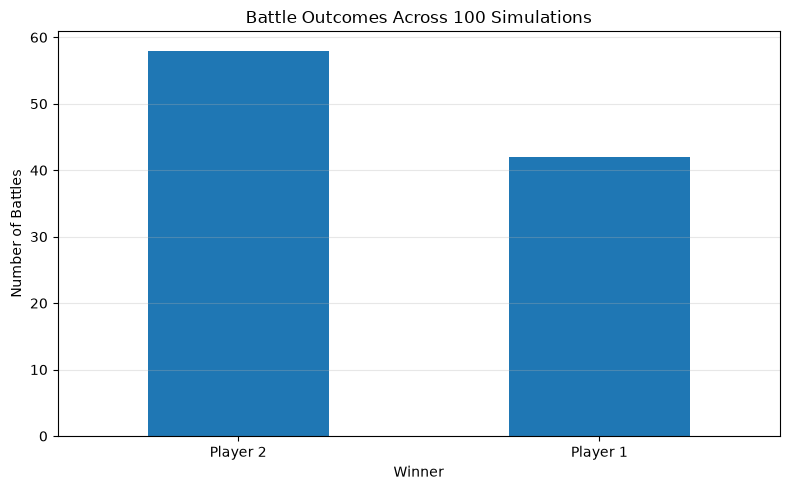

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

winner_counts.plot(
    kind="bar"
)

plt.title("Battle Outcomes Across 100 Simulations")
plt.xlabel("Winner")
plt.ylabel("Number of Battles")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [103]:
import pickle

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

# Save decks

with open(PROCESSED_DIR / "starter_deck.pkl", "wb") as f:
    pickle.dump(starter_deck, f)

with open(PROCESSED_DIR / "lightning_deck.pkl", "wb") as f:
    pickle.dump(lightning_deck, f)

print("Decks saved.")

Decks saved.


In [106]:
simulation_results

,battle_number,winner,turns_completed,rounds_completed,turn_limit_reached,player_one_mulligans,player_two_mulligans
0,1,Player 2,16,8,False,0,0
1,2,Player 1,15,8,False,0,0
2,3,Player 1,15,8,False,0,0
3,4,Player 1,33,17,False,0,0
4,5,Player 2,30,15,False,0,0
...,...,...,...,...,...,...,...
95,96,Player 1,13,7,False,0,0
96,97,Player 1,21,11,False,0,0
97,98,Player 1,49,25,False,3,0
98,99,Player 2,24,12,False,0,0


In [107]:
simulation_output_file = (
    PROCESSED_DIR / "prototype_battle_results.csv"
)

simulation_results.to_csv(
    simulation_output_file,
    index=False
)

print("Prototype battle results saved.")
print(simulation_output_file)

Prototype battle results saved.
D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\notebooks\data\processed\prototype_battle_results.csv


In [108]:
artifact_files = [
    PROCESSED_DIR / "card_knowledge_base.pkl",
    PROCESSED_DIR / "starter_deck.pkl",
    PROCESSED_DIR / "lightning_deck.pkl",
    PROCESSED_DIR / "prototype_battle_results.csv"
]

for file in artifact_files:
    print(file.name, "->", file.exists())

card_knowledge_base.pkl -> True
starter_deck.pkl -> True
lightning_deck.pkl -> True
prototype_battle_results.csv -> True
